In [9]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

dos estrellas con un planeta orbitando alreedor de una de ellas

In [10]:
G = 1

vectores relativos

In [11]:
#Aa: estrella
#Ab: planeta
#A: ambos
#B: estrella

m_Aa = 1
m_Ab = 0.01
m_Aab = m_Aa + m_Ab
m_B = 1

r_A = np.array([0.1, 0.0, 0.0])
v_A = np.array([0.0, 4.0, 0.0])
r_AB = np.array([0.1,0,0])
v_AB = np.array([0,1,0])


Armar el sistema - se comienza definiendo el CM de todo el sistema

In [12]:
#CM de todo el sistema
RCM_AB = np.array([0,0,0])
VCM_AB = np.array([0,0,0])

Se desciende por el grafo

In [13]:
#equivalente a la particula 2 (estrella B)
r_B = RCM_AB - (m_Aab) / (m_Aab + m_B) * r_AB
v_B = VCM_AB - (m_Aab) / (m_Aab + m_B) * v_AB

#equivalente a la particula 1 (estrella Aa y planeta Ab)
RCM_A = RCM_AB + (m_B) / (m_Aab + m_B) * r_AB
VCM_A = VCM_AB + (m_B) / (m_Aab + m_B) * v_AB

In [14]:
#particula 1 de A
r_Aa = RCM_A + (m_Ab) / (m_Aab) * r_A
v_Aa = VCM_A + (m_Ab) / (m_Aab) * v_A

#particula 2 de A
r_Ab = RCM_A - (m_Aa) / (m_Aab) * r_A
v_Ab = VCM_A - (m_Aa) / (m_Aab) * v_A

In [15]:
sistema = [
    dict(m = m_Aa, r = r_A, v = v_A),
    dict(m = m_Ab, r = r_AB, v = v_AB),
    dict(m = m_B, r = r_B, v = v_B)
]
ts = np.linspace(0, 10, 1000)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

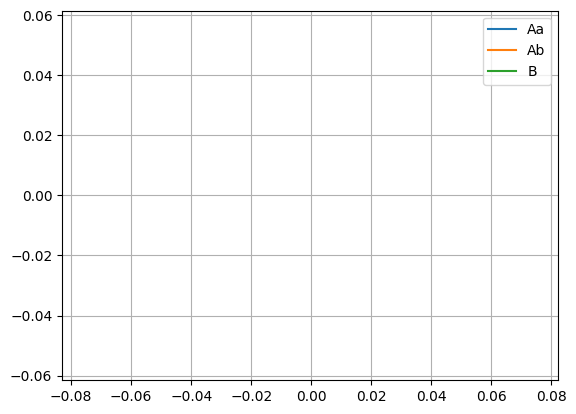

In [16]:
plt.plot(rps[0, :, 0], rps[0, :, 1], '-', label='Aa')
plt.plot(rps[1, :, 0], rps[1, :, 1], '-', label='Ab')
plt.plot(rps[2, :, 0], rps[2, :, 1], '-', label='B')
plt.legend()
plt.axis('equal')
plt.grid()